# Assignment 1
Analyze Canadian health & income data. \
Dataset: `Canadian_Health_Survey_Sample.csv`

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# from google.colab import drive
# import os

# # Run mount on Colab website if authorization fails in Vscode
# drive.mount('/content/drive')   # Mounting personal Google Drive to Colab linux server
# # uploaded = files.upload("Canadian_Health_Survey_Sample.csv")
# # os.listdir('/content/drive')

## Part A – Understanding the Data

### A1) Load CSV

In [117]:
df = pd.read_csv("Canadian_Health_Survey_Sample.csv")

### A2) Information

In [118]:
df.head()

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
0,Ontario,female,59,80572.0,25.7,3.8,yes,Good,6.0
1,New Brunswick,Male,38,125739.0,24.2,3.4,No,Good,9.0
2,Nova Scotia,M,31,55997.0,35.7,NaN,No,Excellent,NaN
3,Saskatchewan,Male,30,75947.0,28.3,3.9,No,Excellent,10.0
4,Saskatchewan,female,79,113966.0,31.2,1.6,No,Fair,6.0


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Province          850 non-null    object 
 1   Gender            850 non-null    object 
 2   Age               850 non-null    int64  
 3   Income            816 non-null    float64
 4   BMI               808 non-null    float64
 5   PhysicalActivity  825 non-null    float64
 6   Smoking           850 non-null    object 
 7   SelfRatedHealth   850 non-null    object 
 8   StressLevel       825 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 59.9+ KB


In [120]:
df.describe(include='all')

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel
count,850,850,850.000000,816.000000,808.000000,825.000000,850,850,825.000000
unique,10,6,NaN,NaN,NaN,NaN,6,5,NaN
top,Quebec,Male,NaN,NaN,NaN,NaN,No,Good,NaN
freq,100,230,NaN,NaN,NaN,NaN,552,258,NaN
mean,NaN,NaN,49.517647,77461.917892,27.488861,3.511394,NaN,NaN,5.294545
std,NaN,NaN,18.192604,22497.833440,5.064344,1.925825,NaN,NaN,2.121156
min,NaN,NaN,18.000000,5000.000000,13.500000,0.000000,NaN,NaN,1.000000
25%,NaN,NaN,33.000000,63438.000000,24.000000,2.100000,NaN,NaN,4.000000
50%,NaN,NaN,49.000000,78130.000000,27.300000,3.500000,NaN,NaN,5.000000
75%,NaN,NaN,66.000000,90529.500000,30.900000,4.700000,NaN,NaN,7.000000


### A3) Attributes
**Quantitative Attribute:** Age - Numerical and ordered.\
Age is just a number. Age is ordered as it has a size to it, 15 years old is younger than 20 years old.\
**Qualitative Attribute:** Province - Categorical and unordered.\
Province is a string category. Province does not have a size, it does not make sense to say one pronvicne is greater than another.

## Part B – Cleaning & Structuring

### B1) Normalization
Standardize naming for values.

In [121]:
# Check all existing values for genders
df["Gender"].unique()

array(['female', 'Male', 'M', 'F', 'Female', 'male'], dtype=object)

In [122]:
# Normalize
gender_map = {
    "male": "Male",
    "m": "Male",
    "female": "Female",
    "f": "Female"
}

df["Gender"] = df["Gender"].str.lower().map(gender_map)

df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [123]:
# Check all existing values for smoking
df["Smoking"].unique()

array(['yes', 'No', 'Y', 'Yes', 'N', 'no'], dtype=object)

In [124]:
# Normalize
smoking_map = {
    "yes": "Yes",
    "y": "Yes",
    "no": "No",
    "n": "No"
}

df["Smoking"] = df["Smoking"].str.lower().map(smoking_map)

df["Smoking"].unique()

array(['Yes', 'No'], dtype=object)

### B2) Dropna / Imputation
Remove or replace 'nan' values.
| Variable         | Approach              | Reason                                                     |
| ---------------- | --------------------- | ---------------------------------------------------------- |
| BMI              | Median imputation     | BMI is continuous and can have outliers → median is robust. |
| Income           | Median imputation     | Income is usually skewed → median better than mean.         |
| StressLevel      | Median imputation     | Ordinal numeric (1–10), no huge skew, median is safe.       |
| PhysicalActivity | Median imputation     | Depends on % missing, if few rows missing, median is fine.    |


In [125]:
# Check nan counts per column
df[["BMI", "Income", "StressLevel", "PhysicalActivity"]].isna().sum()

BMI                 42
Income              34
StressLevel         25
PhysicalActivity    25
dtype: int64

In [126]:
# Handle nan values
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["Income"] = df["Income"].fillna(df["Income"].median())
df["StressLevel"] = df["StressLevel"].fillna(df["StressLevel"].median())
df["PhysicalActivity"] = df["PhysicalActivity"].fillna(df["PhysicalActivity"].median())

df[["BMI", "Income", "StressLevel", "PhysicalActivity"]].isna().sum()

BMI                 0
Income              0
StressLevel         0
PhysicalActivity    0
dtype: int64

### B3) Data Typing
Cast values to preferred data type.

In [127]:
# Check exiting data types
df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel         float64
dtype: object

In [128]:
# Enforce data types
df["Age"] = df["Age"].astype(int)
df["Income"] = df["Income"].astype(float)
df["BMI"] = df["BMI"].astype(float)
df["StressLevel"] = df["StressLevel"].astype(int)

df.dtypes

Province             object
Gender               object
Age                   int64
Income              float64
BMI                 float64
PhysicalActivity    float64
Smoking              object
SelfRatedHealth      object
StressLevel           int64
dtype: object

### B4) Derivation
Get derived values from exisitng data.
| BMI Category | BMI Range |
| ------------ | --------- |
| Underweight  | < 18.5    |
| Normal       | 18.5–24.9 |
| Overweight   | 25–29.9   |
| Obese        | ≥ 30      |

In [129]:
# Create derived columns
df["BMI_Category"] = pd.cut(
    df["BMI"],
    bins=[0, 18.5, 25, 30, float('inf')],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    right=False
)

df["IncomeBracket"] = pd.cut(
    df["Income"],
    bins=[0, 50000, 80000, 110000, float('inf')],
    labels=["<50k", "50-80k", "80-110k", ">110k"],
    right=False
)

df[["BMI", "BMI_Category", "Income", "IncomeBracket"]].head()

,BMI,BMI_Category,Income,IncomeBracket
0,25.7,Overweight,80572.0,80-110k
1,24.2,Normal,125739.0,>110k
2,35.7,Obese,55997.0,50-80k
3,28.3,Overweight,75947.0,50-80k
4,31.2,Obese,113966.0,>110k


## Part C – Visualization

### C1) Bar Chart

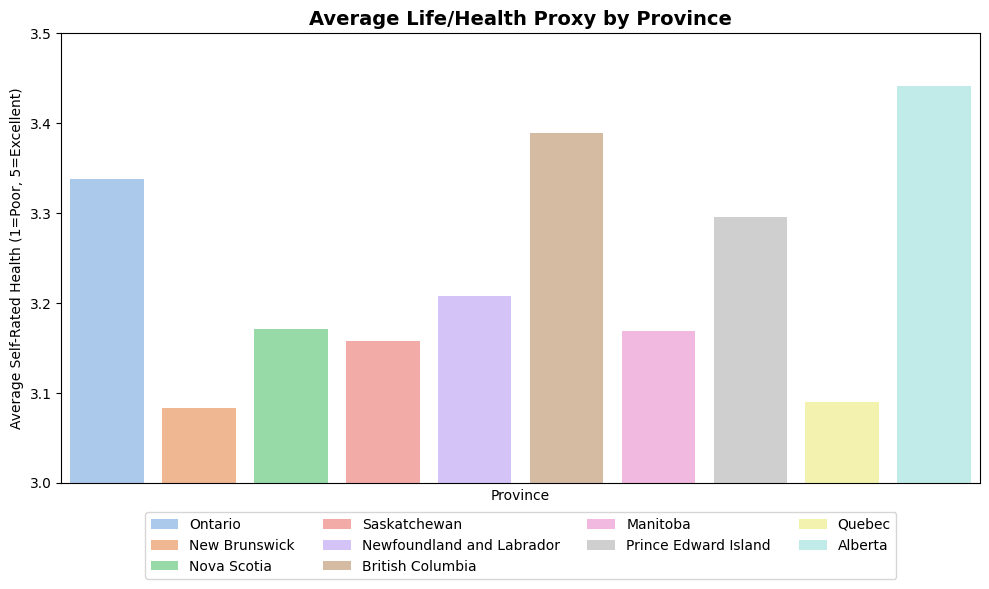

In [130]:
# Bar chart
health_map = {
    "Poor": 1,
    "Fair": 2,
    "Good": 3,
    "Very Good": 4,
    "Excellent": 5
}

df["SelfRatedHealthNumber"] = df["SelfRatedHealth"].map(health_map)
# order = df.groupby("Province")["SelfRatedHealthNumber"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Province", y="SelfRatedHealthNumber", hue="Province", legend=True, errorbar=None, palette="pastel")

plt.title("Average Life/Health Proxy by Province", fontsize=14, fontweight='bold')
plt.ylabel("Average Self-Rated Health (1=Poor, 5=Excellent)")

plt.xticks([])              # disable province name labels and use legends only
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=4, frameon=True)     # add legend to bottom
plt.ylim(3, 3.5)            # zoom y-axis to focus between 3.0 to 3.5 where all values lie
plt.tight_layout()

plt.show()

### C2) Scatterplot

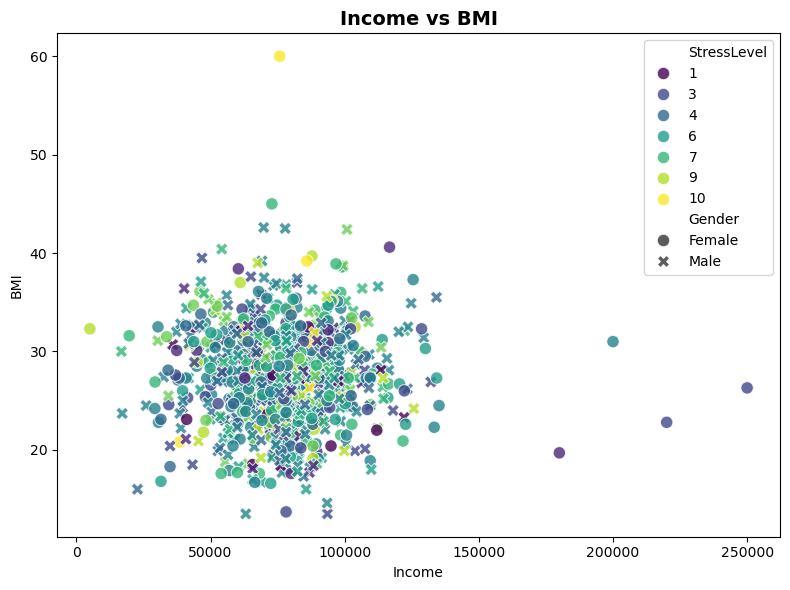

In [79]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x="Income", y="BMI", hue="StressLevel", style="Gender", palette="viridis", s=80, alpha=0.8)

plt.title("Income vs BMI", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### C3) Diverging Visualization

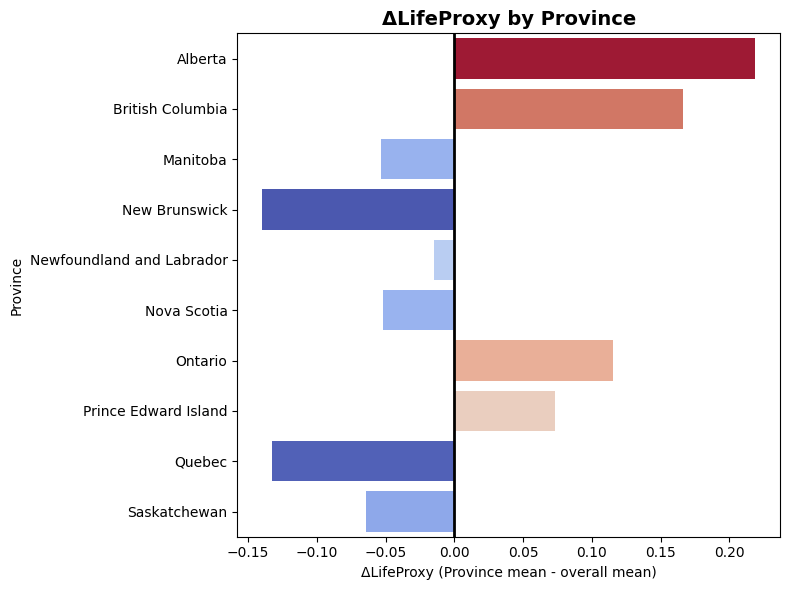

,Province,Gender,Age,Income,BMI,PhysicalActivity,Smoking,SelfRatedHealth,StressLevel,BMI_Category,IncomeBracket,SelfRatedHealthNumber
828,Newfoundland and Labrador,Male,72,94959.0,29.6,2.8,Yes,Poor,5,Overweight,80-110k,1
17,Quebec,Female,57,97771.0,26.8,4.8,No,Poor,8,Overweight,80-110k,1
846,Quebec,Female,46,78130.0,13.7,3.0,Yes,Poor,3,Underweight,50-80k,1
241,Manitoba,Female,27,78130.0,29.2,5.4,No,Poor,4,Overweight,50-80k,1
258,Quebec,Female,67,98507.0,36.0,2.1,No,Poor,7,Obese,80-110k,1
...,...,...,...,...,...,...,...,...,...,...,...,...
815,Newfoundland and Labrador,Male,65,59848.0,31.8,1.4,No,Excellent,4,Obese,50-80k,5
444,Manitoba,Male,66,93437.0,14.6,4.1,No,Excellent,5,Underweight,80-110k,5
840,British Columbia,Female,33,102638.0,22.6,4.1,No,Excellent,7,Normal,80-110k,5
835,New Brunswick,Male,33,99813.0,19.9,6.1,Yes,Excellent,9,Normal,80-110k,5


In [ ]:
overall_mean = df["SelfRatedHealthNumber"].mean()
delta_life = df.groupby("Province")["SelfRatedHealthNumber"].mean() - overall_mean
# df["ΔLifeProxy"] = df.groupby("Province")["SelfRatedHealthNumber"].transform("mean") - overall_mean       # not useful, but interesting

plt.figure(figsize=(8,6))

sns.barplot(
    x=delta_life.values,
    y=delta_life.index,
    hue=delta_life.values,
    orient="h",
    palette="coolwarm",
    legend=False
)

plt.title("ΔLifeProxy by Province", fontsize=14, fontweight='bold')
plt.xlabel("ΔLifeProxy (Province mean - overall mean)")

plt.axvline(0, color="black", linewidth=2)

plt.tight_layout()
plt.show()

### C4) Design Choices
1. **Types of data**
- Quantitative/numerical continuous: C1 average self-rated health, C2 BMI, income
- Quantitative/numerical discrete: C2 stress level, C3 delta life proxy (by province)
- Qualitative/categorical unordered: C1 provinces, C2 genders, C3 provinces
1. **Color Scale**
- Colors - different color to represent categorical data. E.g. the colors in the bar chart in C1 are used to represent different provinces.
- Hues - a saturation gradient to represent numerical data. E.g. the blue to red hue in C3 is used to represent the negative to positive delta life proxy.
2. **Shapes**
- different shapes to represent categorical data E.g. different shapes are used along side color in C2 to represent male and female.
3. **Cognitive Load Theory (CLT)**
- Redundancy - no labels or other data are repeated in the charts.
- Coherence - no unnecessary information are presented in the charts.
- Signaling - the title of the charts are bold cased.